In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/train.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.shape

(9800, 18)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [8]:
#checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [10]:
#checking for missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [11]:
#removing the missing values
df = df.dropna()

In [12]:
#Now, to find the region with the highest sales
sales_region = df.groupby("Region")["Sales"].sum()

In [13]:
sales_region

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

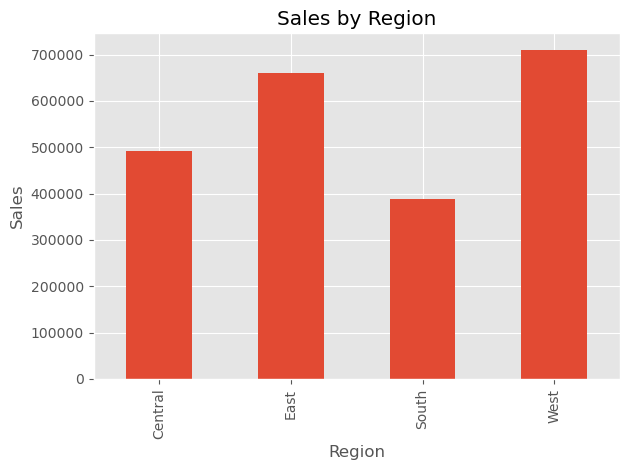

In [14]:
sales_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../images/sales_by_region.png")

plt.show()

#### The West region generated the highest sales revenue, suggesting strong market demand. The company should continue investing in this region while investigating why lower-performing regions are underperforming.

In [15]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,8/11/2017,11/11/2017
1,8/11/2017,11/11/2017
2,12/6/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,9/6/2015,14/06/2015
6,9/6/2015,14/06/2015
7,9/6/2015,14/06/2015
8,9/6/2015,14/06/2015
9,9/6/2015,14/06/2015


In [16]:
# Split Order Date into day, month and year
order_date = df["Order Date"].str.split("/", expand=True)

df["Order Date"] = pd.to_datetime({
    "year": order_date[2],
    "month": order_date[1],
    "day": order_date[0]
})

# Split Ship Date into day, month and year
ship_date = df["Ship Date"].str.split("/", expand=True)

df["Ship Date"] = pd.to_datetime({
    "year": ship_date[2],
    "month": ship_date[1],
    "day": ship_date[0]
})

In [17]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18
5,2015-06-09,2015-06-14
6,2015-06-09,2015-06-14
7,2015-06-09,2015-06-14
8,2015-06-09,2015-06-14
9,2015-06-09,2015-06-14


In [18]:
#Lets find the top 10 products
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

In [19]:
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

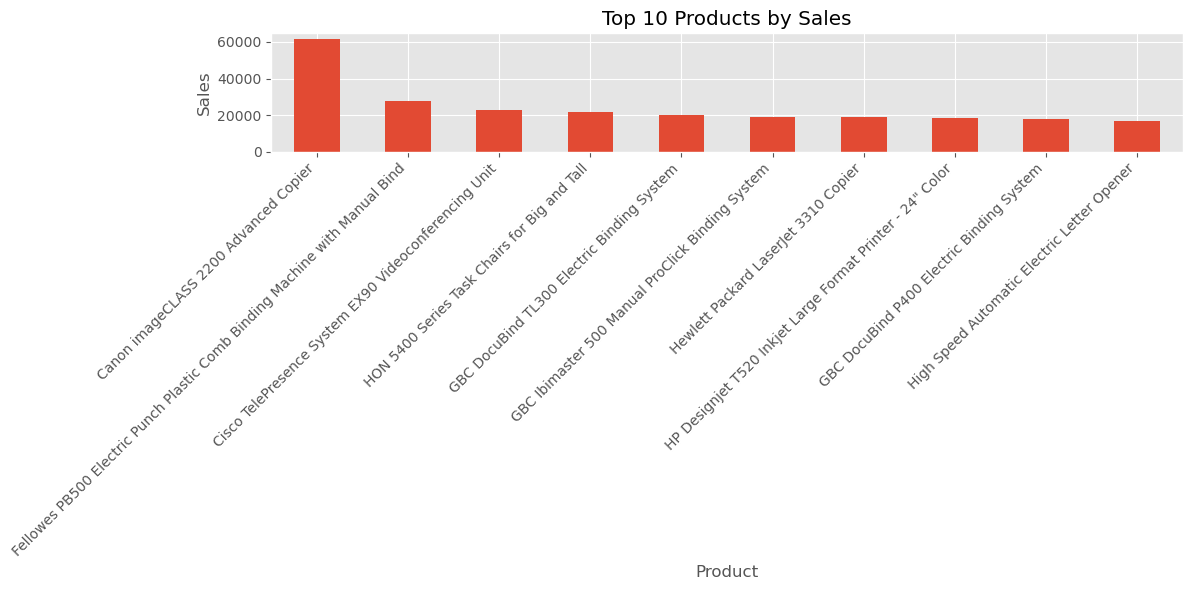

In [20]:
top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../images/top_10_products.png")

plt.show()

#### "Canon imageCLASS 2200 Advanced Copier" was the most purchased product.

In [21]:
#Lets see if we can get monthly sales. First create a"Month" column.
df["Month"] = df["Order Date"].dt.month_name()

In [22]:
#Now to make the months appear in calendar form
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

In [23]:
#Now calculating monthly sales
monthly_sales = df.groupby("Month")["Sales"].sum()

In [24]:
monthly_sales

Month
January       91982.1396
February      59371.1154
March        197573.5872
April        134988.2506
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     345041.6110
December     321275.1395
Name: Sales, dtype: float64

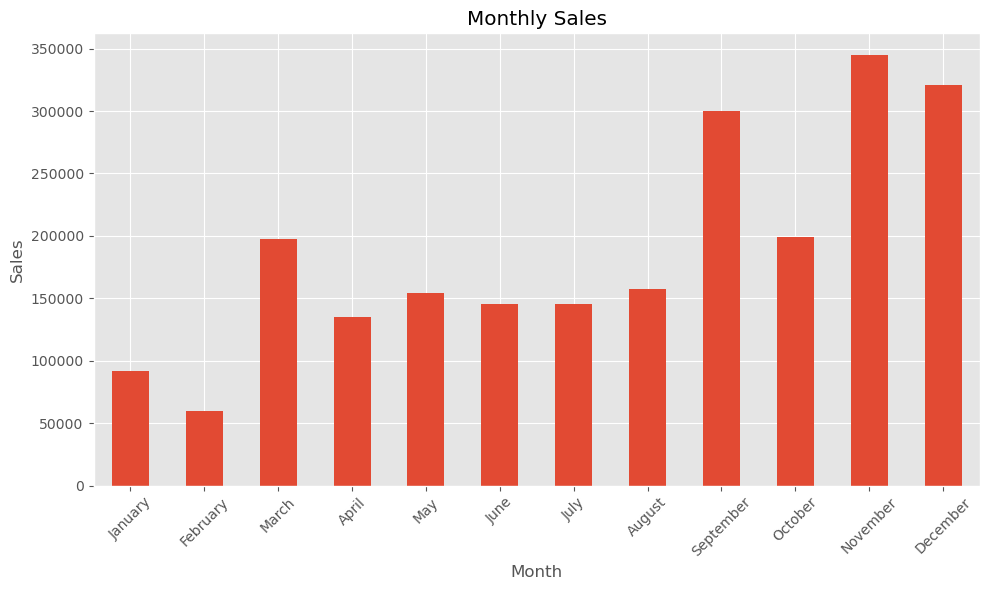

In [25]:
monthly_sales.plot(kind="bar", figsize=(10,6))

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/monthly_sales.png")

plt.show()

#### November recorded the highest sales, likely due to seasonal shopping trends and promotional events. Management should prepare additional inventory and marketing campaigns ahead of this period to maximize revenue